# Missing Value

Missing value merupakan kondisi ketika suatu atribut pada dataset tidak memiliki nilai atau terdapat data yang hilang. Kondisi ini dapat terjadi karena berbagai faktor, seperti kesalahan saat proses pengumpulan data, data yang tidak tercatat, maupun kesalahan dalam proses penyimpanan data.

Apabila missing value tidak ditangani dengan baik, hal tersebut dapat mempengaruhi hasil analisis serta menurunkan kualitas model yang digunakan. Oleh karena itu diperlukan metode imputasi untuk mengisi nilai yang hilang sehingga dataset dapat digunakan secara lebih optimal.

Pada analisis ini, proses penanganan missing value dilakukan menggunakan metode **Weighted K-Nearest Neighbor (WKNN).**

## Dataset

Dataset yang digunakan pada tugas ini terdiri dari atribut **tinggi** dan **berat**.
Pada data berikut terdapat missing value pada atribut berat.

Pada Excel

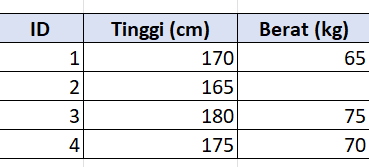

Pada Python


In [1]:
import pandas as pd
import numpy as np

data = {
    "ID":[1,2,3,4],
    "Tinggi":[170,165,180,175],
    "Berat":[65,np.nan,75,70]
}

df = pd.DataFrame(data)
df

ModuleNotFoundError: No module named 'pandas'

**np.nan** digunakan untuk menunjukkan bahwa nilai berat tidak diketahui / hilang.

Pada kasus ini menunjukkan bahwa nilai berat untuk tinggi 165 cm tidak tersedia, sehingga perlu dilakukan imputasi menggunakan metode WKNN.

## Implementasi WKNN di Excel

Pada tahap pertama perhitungan missing value dilakukan secara manual
menggunakan Microsoft Excel.

Langkah perhitungan:

1. Menghitung Distance

   Distance digunakan untuk mengetahui jarak antara tinggi data yang memiliki missing value dengan data lainnya.

   Rumus:

   Distance = |Xi - X|

   Keterangan:

   Xi = tinggi data ke-i

   X = tinggi data yang memiliki missing value

   Rumus Excel:

   **=ABS(B4-$B$5)**

   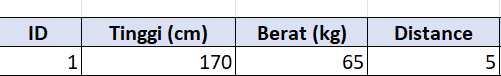
   

2. Menghitung Weight  
   Weight dihitung untuk memberikan bobot pada setiap data berdasarkan jaraknya.

   Rumus:

   Weight = 1 / Distance

   Rumus Excel:

   **=1/D4**

   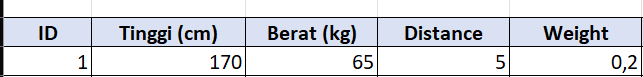

3. Menghitung Weight × Berat
   Nilai ini digunakan untuk menghitung kontribusi setiap tetangga terhadap estimasi nilai.

   Rumus:

   Weight × Berat = Weight * Berat

   Rumus Excel:
 
   **=E4*C4**

   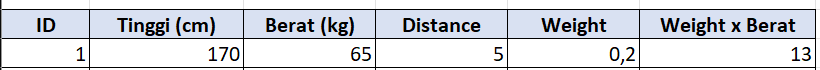

4. Menghitung hasil estimasi

Nilai berat yang hilang dihitung dengan rumus:

Estimasi = Σ(Weight × Berat) / ΣWeight

Rumus Excel:

**=SUM(F4;F6;F7)/SUM(E4;E6;E7)**

Hasil perhitungan:

(13 + 5 + 7) / (0.2 + 0.0667 + 0.1)
= 68.18

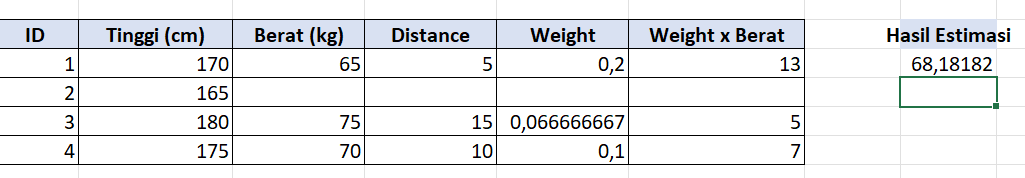

## Implementasi WKNN Menggunakan Python

Menghitung Distance

In [2]:
missing_height = 165

df["Distance"] = abs(df["Tinggi"] - missing_height)
df

,ID,Tinggi,Berat,Distance
0,1,170,65.0,5
1,2,165,NaN,0
2,3,180,75.0,15
3,4,175,70.0,10


Menghitung Weight

In [3]:
df["Weight"] = 1 / df["Distance"]
df

,ID,Tinggi,Berat,Distance,Weight
0,1,170,65.0,5,0.200000
1,2,165,NaN,0,inf
2,3,180,75.0,15,0.066667
3,4,175,70.0,10,0.100000


Menghitung Weight × Berat

In [4]:
df["Weight_x_Berat"] = df["Weight"] * df["Berat"]
df

,ID,Tinggi,Berat,Distance,Weight,Weight_x_Berat
0,1,170,65.0,5,0.200000,13.0
1,2,165,NaN,0,inf,NaN
2,3,180,75.0,15,0.066667,5.0
3,4,175,70.0,10,0.100000,7.0


Menghitung Hasil WKNN

In [13]:
import pandas as pd
import numpy as np

# 1. Masukkan data sesuai tabel Excel
data = {
    "ID": [1, 2, 3, 4],
    "Tinggi": [170, 165, 180, 175],
    "Berat": [65, np.nan, 75, 70],
    "Distance": [5, np.nan, 15, 10] # ID 2 kosong karena itu yang dicari
}

df = pd.DataFrame(data)

# 2. Hitung Weight (1 / Distance)
df["Weight"] = 1 / df["Distance"]

# 3. Hitung Weight x Berat
df["Weight_x_Berat"] = df["Weight"] * df["Berat"]

# 4. Hitung Hasil Estimasi (Hanya untuk baris yang punya data Berat)
mask = df["Berat"].notna()
numerator = df.loc[mask, "Weight_x_Berat"].sum()
denominator = df.loc[mask, "Weight"].sum()

hasil_estimasi = numerator / denominator

print(f"Total Weight x Berat: {numerator}")
print(f"Total Weight: {denominator}")
print(f"Hasil Estimasi: {hasil_estimasi}")

Total Weight x Berat: 25.0
Total Weight: 0.3666666666666667
Hasil Estimasi: 68.18181818181817


In [15]:
import pandas as pd
import numpy as np

# 1. Data Input
data = {
    "ID": [1, 2, 3, 4],
    "Tinggi": [170, 165, 180, 175],
    "Berat": [65, np.nan, 75, 70],
    "Distance": [5, np.nan, 15, 10] # Biarkan NaN untuk yang dicari
}
df = pd.DataFrame(data)

# 2. Hitung Weight (Hanya pada baris yang punya Distance)
# Ini mencegah pembagian dengan nol (1/0)
df["Weight"] = 1 / df["Distance"]

# 3. Hitung Weight x Berat
df["Weight_x_Berat"] = df["Weight"] * df["Berat"]

# 4. Ambil angka untuk pembilang dan penyebut
# Kita hanya hitung baris 1, 3, dan 4 (yang Berat-nya tidak NaN)
mask = df["Berat"].notna()
numerator = df.loc[mask, "Weight_x_Berat"].sum()
denominator = df.loc[mask, "Weight"].sum()

hasil_estimasi = numerator / denominator

# 5. ISI ID 2 dengan hasil tersebut
df.loc[df["Berat"].isna(), "Berat"] = hasil_estimasi

# Tampilkan hasil
print(f"Hasil Estimasi: {hasil_estimasi}")
df

Hasil Estimasi: 68.18181818181817


,ID,Tinggi,Berat,Distance,Weight,Weight_x_Berat
0,1,170,65.000000,5.0,0.200000,13.0
1,2,165,68.181818,NaN,NaN,NaN
2,3,180,75.000000,15.0,0.066667,5.0
3,4,175,70.000000,10.0,0.100000,7.0


# Normalisasi Data

Normalisasi adalah proses mengubah nilai data ke dalam skala yang sama
agar tidak terjadi perbedaan skala yang terlalu besar antar atribut.

Normalisasi sangat penting pada algoritma machine learning
seperti KNN, SVM, dan Neural Network.

## Jenis Normalisasi

1. Min-Max Normalization
2. Z-Score Normalization
3. Decimal Scaling

Disini saya membuat tabel baru dengan isi :

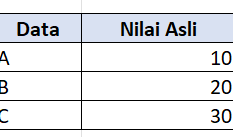

In [ ]:
import pandas as pd
import numpy as np

data = {
    'Data': ['A', 'B', 'C'],
    'Nilai Asli': [10, 20, 30]
}
df = pd.DataFrame(data)
df

,Data,Nilai Asli
0,A,10
1,B,20
2,C,30



### 1. Min-Max Normalization
Metode ini mentransformasi data asli ke dalam rentang **0 hingga 1**. Nilai terkecil akan menjadi 0, dan nilai terbesar akan menjadi 1.

* **Rumus Matematis:** $$v' = \frac{v - min_A}{max_A - min_A}$$
* **Implementasi Excel (Baris 4):** `=(B4-MIN($B$4:$B$6))/(MAX($B$4:$B$6)-MIN($B$4:$B$6))`
* **Logika Perhitungan (Data A):** $(10 - 10) / (30 - 10) = 0 / 20 = \mathbf{0}$



---

### 2. Z-Score Normalization
Metode ini menormalisasi data berdasarkan nilai rata-rata (*mean*) dan standar deviasi. Hasilnya akan menunjukkan seberapa jauh data tersebut menyimpang dari titik tengahnya.

* **Rumus Matematis:** $$v' = \frac{v - \mu_A}{\sigma_A}$$
* **Implementasi Excel (Baris 4):** `=(B4-AVERAGE($B$4:$B$6))/STDEV.P($B$4:$B$6)`
* **Logika Perhitungan (Data A):** $(10 - 20) / 10 = -10 / 10 = \mathbf{-1}$



---

### 3. Decimal Scaling
Metode ini menormalisasi data dengan menggerakkan koma desimal berdasarkan angka dengan digit terbanyak pada kumpulan data.

* **Rumus Matematis:** $$v' = \frac{v}{10^j}$$
* **Implementasi Excel (Baris 4):** `=B4/100`
* **Logika Perhitungan (Data A):** Karena angka terbesar (30) memiliki 2 digit, maka pembaginya adalah $10^2 = 100$. Hasilnya: $10 / 100 = \mathbf{0,1}$



---

### Hasil Perhitungan Akhir

| Data | Nilai Asli | Min-Max | Z-Score | Decimal Scaling |
| :--- | :--- | :--- | :--- | :--- |
| **A** | 10 | 0 | -1 | 0,1 |
| **B** | 20 | 0,5 | 0 | 0,2 |
| **C** | 30 | 1 | 1 | 0,3 |

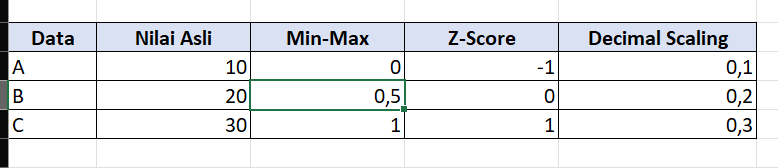

### Normaliasi Python

In [ ]:
v_min = df['Nilai Asli'].min()
v_max = df['Nilai Asli'].max()
df['Min-Max'] = (df['Nilai Asli'] - v_min) / (v_max - v_min)

df

,Data,Nilai Asli,Min-Max,Z-Score,Decimal Scaling
0,A,10,0.0,-1.224745,0.1
1,B,20,0.5,0.000000,0.2
2,C,30,1.0,1.224745,0.3
